# Clasificación de sentimientos mediante TF-IDF y Regresión Logística

## 1. Introducción

En este notebook construimos un clasificador de sentimientos para reseñas de productos en español, usando TF-IDF para representar el texto y Regresión Logística como clasificador. Cada reseña debe clasificarse como positiva, negativa o neutral.

TF-IDF convierte cada reseña en un vector numérico, donde el peso de cada término depende de qué tan frecuente es en la reseña y de qué tan común es en el resto del corpus. La Regresión Logística aprende a partir de esos vectores a separar las tres clases.

El trabajo sigue el flujo de las prácticas del curso: preparación de los datos, construcción del pipeline, entrenamiento, evaluación y búsqueda de hiperparámetros. Como en la competencia, la métrica principal es la accuracy.

## 2. Importación de librerías

Usamos pandas y NumPy para manejar los datos y scikit-learn para la representación del texto, el entrenamiento y la evaluación.

`TfidfVectorizer` transforma las reseñas en matrices dispersas y `LogisticRegression` es el clasificador multiclase. Ambos se integran en un `Pipeline`, de modo que el vectorizador se ajuste solo con los datos de entrenamiento y no haya fuga de información hacia validación.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## 3. Carga y preparación de los datos

Cargamos el conjunto de entrenamiento de la competencia, con 12.000 reseñas etiquetadas.

Hacemos una partición estratificada 80/20 con la misma semilla que en el notebook de exploración, para que todos los modelos del equipo se comparen sobre las mismas 2.400 reseñas de validación. El archivo `eval.csv` de Kaggle no se usa en esta etapa; solo sirve para generar las predicciones del envío.

In [3]:
# Ubicación de los archivos
data_dir = Path("data")

if not data_dir.exists():
    data_dir = Path("../data")

# Cargar los datos
train = pd.read_csv(data_dir / "train.csv")

# Separar variables
X = train["text"]
y = train["label"]

# División de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", len(X_train))
print("Datos de validación:", len(X_val))

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribución en validación:")
print(y_val.value_counts(normalize=True).round(3))


Datos de entrenamiento: 9600
Datos de validación: 2400

Distribución en entrenamiento:
label
positivo    0.351
negativo    0.351
neutral     0.298
Name: proportion, dtype: float64

Distribución en validación:
label
negativo    0.351
positivo    0.351
neutral     0.298
Name: proportion, dtype: float64


## 4. Construcción del pipeline

El primer pipeline tiene dos pasos: `TfidfVectorizer` con sus parámetros por defecto (solo unigramas) y `LogisticRegression` con `max_iter=1000` para que el optimizador alcance a converger.

Este modelo sencillo nos sirve como punto de referencia para medir después si los n-gramas y el ajuste de hiperparámetros mejoran el desempeño.

In [4]:
# Pipeline inicial
pipeline_rl = Pipeline(steps=[
    (
        "tfidf",
        TfidfVectorizer()
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

pipeline_rl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 5. Entrenamiento del modelo

Entrenamos el pipeline con las 9.600 reseñas de entrenamiento. En este paso el vectorizador construye el vocabulario y calcula los pesos TF-IDF, y la Regresión Logística ajusta sus coeficientes. Las reseñas de validación no se usan aquí.

In [6]:
# Entrenar el pipeline completo
pipeline_rl.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['negativo','neutral','positivo']"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


## 6. Evaluación del modelo inicial

Evaluamos el modelo sobre las 2.400 reseñas de validación. Además de la accuracy, revisamos el reporte de clasificación (precision, recall y F1-score) para ver cómo le va al modelo en cada clase.

In [7]:
# Generar predicciones
y_pred = pipeline_rl.predict(X_val)

# Calcular accuracy
accuracy = accuracy_score(y_val, y_pred)

print(f"Accuracy de validación: {accuracy:.4f}")
print(f"Accuracy en porcentaje: {accuracy * 100:.2f}%")

# Reporte por categoría
print("\nReporte de clasificación:")
print(classification_report(y_val, y_pred))


Accuracy de validación: 0.7275
Accuracy en porcentaje: 72.75%

Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.62      0.61      0.62       843
     neutral       0.96      1.00      0.98       715
    positivo       0.62      0.61      0.62       842

    accuracy                           0.73      2400
   macro avg       0.74      0.74      0.74      2400
weighted avg       0.72      0.73      0.73      2400



### 6.1. Matriz de confusión

La matriz de confusión compara las etiquetas reales con las predichas. La diagonal muestra los aciertos y el resto de celdas muestra entre qué clases se equivoca el modelo.

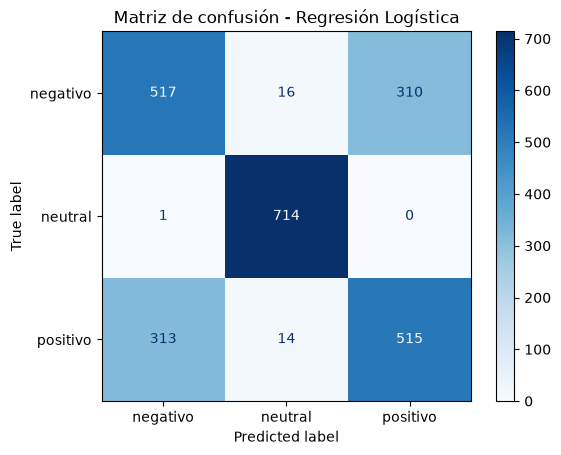

In [8]:
# Orden de las categorías
clases = ["negativo", "neutral", "positivo"]

# Matriz de confusión
matriz = confusion_matrix(
    y_val,
    y_pred,
    labels=clases
)

# Visualización
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=clases
)

disp.plot(cmap="Blues")

plt.title("Matriz de confusión - Regresión Logística")
plt.show()


### 6.2. Interpretación de los resultados del modelo inicial

El modelo inicial obtuvo una accuracy de 72,75% en validación, es decir, clasificó bien 1.746 de las 2.400 reseñas.

El desempeño cambia mucho entre clases. La clase neutral tiene un F1-score de 0,98 y un recall cercano a 1, mientras que positiva y negativa se quedan alrededor de 0,62.

La matriz de confusión muestra que casi todos los errores son entre positivo y negativo: 310 reseñas negativas se clasificaron como positivas y 313 positivas como negativas. Al parecer, los unigramas no alcanzan para distinguir opiniones de polaridad opuesta, sobre todo cuando hay negaciones o combinaciones de palabras.

En lo que sigue probamos bigramas, otras configuraciones de TF-IDF y distintos valores de regularización.

## 7. Incorporación de n-gramas

Como el problema principal está entre positivo y negativo, la primera idea es agregar bigramas. Un bigrama conserva pares de palabras seguidas, lo que puede ayudar con expresiones como "no funciona" o "muy bueno", que pierden su sentido si se separan.

Entrenamos una nueva Regresión Logística con `ngram_range=(1, 2)`, dejando los demás parámetros igual.

In [9]:
# Modelo con unigramas y bigramas
pipeline_rl_bigramas = Pipeline(steps=[
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2)
        )
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Entrenamiento
pipeline_rl_bigramas.fit(X_train, y_train)

# Predicciones
y_pred_bigramas = pipeline_rl_bigramas.predict(X_val)

# Evaluación
accuracy_bigramas = accuracy_score(
    y_val,
    y_pred_bigramas
)

print(f"Accuracy modelo inicial: {accuracy:.4f}")
print(f"Accuracy con bigramas: {accuracy_bigramas:.4f}")

print("\nReporte con bigramas:")
print(classification_report(y_val, y_pred_bigramas))


Accuracy modelo inicial: 0.7275
Accuracy con bigramas: 0.7267

Reporte con bigramas:
              precision    recall  f1-score   support

    negativo       0.62      0.61      0.62       843
     neutral       0.97      1.00      0.98       715
    positivo       0.62      0.61      0.61       842

    accuracy                           0.73      2400
   macro avg       0.74      0.74      0.74      2400
weighted avg       0.72      0.73      0.72      2400



In [10]:
comparacion = pd.DataFrame({
    "Modelo": [
        "TF-IDF unigramas",
        "TF-IDF unigramas + bigramas"
    ],
    "Accuracy": [
        accuracy,
        accuracy_bigramas
    ]
})

comparacion["Accuracy (%)"] = (
    comparacion["Accuracy"] * 100
).round(2)

display(comparacion)


,Modelo,Accuracy,Accuracy (%)
0,TF-IDF unigramas,0.727500,72.75
1,TF-IDF unigramas + bigramas,0.726667,72.67


### 7.1. Resultados de la incorporación de bigramas

Con bigramas el modelo obtuvo 72,67% en validación, frente a 72,75% del modelo inicial. La diferencia es de 0,08 puntos, así que en esta configuración los bigramas no ayudaron, y las clases positiva y negativa siguen siendo las más difíciles.

Esto no descarta los bigramas, porque su efecto puede depender de otros parámetros del vectorizador y del clasificador. Por eso el siguiente paso es una búsqueda de hiperparámetros con validación cruzada sobre el conjunto de entrenamiento.

## 8. Optimización de hiperparámetros

Usamos `GridSearchCV` para probar combinaciones de:

- rango de n-gramas: `(1, 1)` y `(1, 2)`,
- frecuencia documental mínima: `min_df` de 1 y 2,
- frecuencia sublineal: `sublinear_tf` activada o no,
- regularización `C`: 0,1, 1, 5 y 20.

La búsqueda se hace solo con las 9.600 reseñas de entrenamiento, con validación cruzada estratificada de tres particiones y accuracy como métrica, igual que en la competencia.

In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Pipeline que vamos a optimizar
pipeline_grid = Pipeline(steps=[
    ("tfidf", TfidfVectorizer()),
    ("modelo", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Parámetros que vamos a probar
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__sublinear_tf": [True, False],
    "modelo__C": [0.1, 1, 5, 20]
}

# Validación cruzada estratificada
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Búsqueda de hiperparámetros
grid_rl = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Entrenar todas las configuraciones
grid_rl.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_rl.best_params_)

print("\nMejor accuracy promedio en validación cruzada:")
print(f"{grid_rl.best_score_:.4f}")


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Mejores hiperparámetros:
{'modelo__C': 5, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}

Mejor accuracy promedio en validación cruzada:
0.7314


In [12]:
# Obtener los resultados de la búsqueda
resultados_grid = pd.DataFrame(grid_rl.cv_results_)

# Seleccionar las columnas principales
columnas = [
    "param_tfidf__ngram_range",
    "param_tfidf__min_df",
    "param_tfidf__sublinear_tf",
    "param_modelo__C",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

# Mostrar las 10 mejores configuraciones
top_10 = resultados_grid[columnas].sort_values(
    by="rank_test_score"
).head(10)

display(top_10)


,param_tfidf__ngram_range,param_tfidf__min_df,param_tfidf__sublinear_tf,param_modelo__C,mean_test_score,std_test_score,rank_test_score
22,"(1, 2)",2,True,5.0,0.731354,0.004850,1
16,"(1, 1)",1,True,5.0,0.730417,0.007656,2
23,"(1, 2)",2,False,5.0,0.730313,0.006600,3
24,"(1, 1)",1,True,20.0,0.729375,0.007539,4
17,"(1, 1)",1,False,5.0,0.729271,0.006971,5
18,"(1, 2)",1,True,5.0,0.729271,0.005764,6
29,"(1, 1)",2,False,20.0,0.728750,0.005935,7
25,"(1, 1)",1,False,20.0,0.728750,0.006000,8
20,"(1, 1)",2,True,5.0,0.727813,0.010244,9
19,"(1, 2)",1,False,5.0,0.727813,0.006140,9


### 8.1. Resultados de la búsqueda de hiperparámetros

Se evaluaron 32 configuraciones con tres particiones, es decir, 96 ajustes.

La mejor configuración obtuvo 73,14% de accuracy promedio, con unigramas y bigramas (`ngram_range=(1,2)`), `min_df=2`, `sublinear_tf=True` y `C=5`. Varias configuraciones quedaron cerca del 73%, así que las diferencias entre ellas son pequeñas.

Comparada con el modelo inicial, la mejor configuración incluye bigramas y una regularización más débil. Falta ver si eso se mantiene en el conjunto de validación.

## 9. Evaluación del modelo optimizado

Evaluamos el mejor pipeline de `GridSearchCV` sobre las 2.400 reseñas de validación y lo comparamos con los dos modelos anteriores. También revisamos la matriz de confusión, con atención a las confusiones entre positivo y negativo.

In [14]:
# Obtener el mejor modelo de GridSearchCV
mejor_modelo_rl = grid_rl.best_estimator_

# Generar predicciones sobre validación
y_pred_optimizado = mejor_modelo_rl.predict(X_val)

# Calcular accuracy
accuracy_optimizada = accuracy_score(
    y_val,
    y_pred_optimizado
)

print("Accuracy modelo inicial:", round(accuracy, 4))
print("Accuracy modelo con bigramas:", round(accuracy_bigramas, 4))
print("Accuracy modelo optimizado:", round(accuracy_optimizada, 4))

print("\nReporte de clasificación del modelo optimizado:")
print(classification_report(y_val, y_pred_optimizado))


Accuracy modelo inicial: 0.7275
Accuracy modelo con bigramas: 0.7267
Accuracy modelo optimizado: 0.7242

Reporte de clasificación del modelo optimizado:
              precision    recall  f1-score   support

    negativo       0.61      0.60      0.61       843
     neutral       0.98      1.00      0.99       715
    positivo       0.61      0.61      0.61       842

    accuracy                           0.72      2400
   macro avg       0.74      0.74      0.74      2400
weighted avg       0.72      0.72      0.72      2400



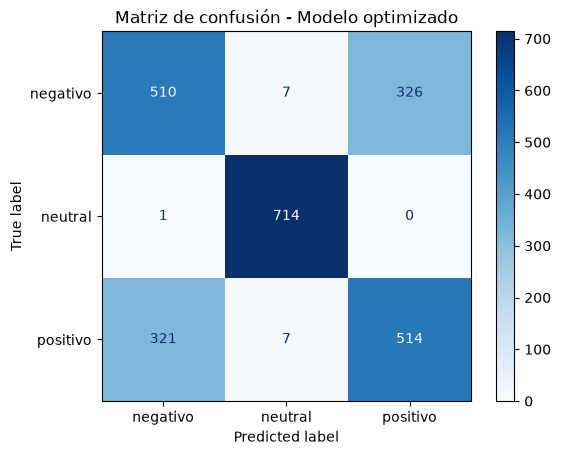

In [15]:
clases = ["negativo", "neutral", "positivo"]

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_optimizado,
    labels=clases,
    display_labels=clases,
    cmap="Blues"
)

plt.title("Matriz de confusión - Modelo optimizado")
plt.show()

### 9.1. Interpretación de los resultados del modelo optimizado

El modelo optimizado obtuvo 72,42% en validación, un poco menos que el 72,75% del modelo inicial. Es decir, la mejora que se vio en validación cruzada (73,14%) no se trasladó a validación, lo que muestra por qué hay que evaluar sobre datos que no participaron en el ajuste.

La clase neutral sigue casi perfecta, con 714 aciertos de 715. En cambio, 326 reseñas negativas se clasificaron como positivas y 321 positivas como negativas. Ni los bigramas ni el ajuste de la regularización resolvieron este problema.

Antes de seguir probando configuraciones, conviene entender mejor qué está aprendiendo el modelo y en qué se equivoca.

## 10. Análisis de las características aprendidas

La Regresión Logística asigna un coeficiente a cada término para cada clase, así que podemos ver qué palabras empujan la predicción hacia cada sentimiento. Revisamos los 15 términos con mayor coeficiente por clase en el modelo inicial.

In [16]:
# Obtener el vectorizador y el clasificador entrenados
vectorizador = pipeline_rl.named_steps["tfidf"]
clasificador = pipeline_rl.named_steps["modelo"]

# Obtener las características y las clases
palabras = vectorizador.get_feature_names_out()
clases_modelo = clasificador.classes_

# Mostrar los términos con mayor coeficiente por clase
for i, clase in enumerate(clases_modelo):
    coeficientes = clasificador.coef_[i]

    indices = np.argsort(coeficientes)[-15:][::-1]

    print(f"\nTérminos asociados a la clase {clase}:")

    tabla = pd.DataFrame({
        "Termino": palabras[indices],
        "Coeficiente": coeficientes[indices]
    })

    display(tabla)



Términos asociados a la clase negativo:


,Termino,Coeficiente
0,pero,2.918123
1,mal,2.842204
2,muy,2.516092
3,harto,2.342893
4,regalado,2.300257
5,resultó,2.272249
6,cuesta,2.158696
7,defraudó,2.129720
8,vale,2.096124
9,error,2.013101



Términos asociados a la clase neutral:


,Termino,Coeficiente
0,trae,2.781122
1,viene,2.747954
2,color,2.659754
3,paquete,2.572147
4,voltios,2.218256
5,siempre,2.166977
6,kilo,2.123116
7,unidades,2.099822
8,caja,2.067490
9,todavía,2.001960



Términos asociados a la clase positivo:


,Termino,Coeficiente
0,verdad,3.135497
1,feliz,2.588300
2,acierto,2.406322
3,pena,2.361940
4,me,2.348256
5,sola,2.325981
6,estrellas,2.300038
7,encima,2.202785
8,maravilla,2.112550
9,superó,2.057319


### 10.1. Análisis de errores de clasificación

Además de los coeficientes, revisamos reseñas mal clasificadas. Para no usar el conjunto de validación, obtenemos predicciones fuera de muestra sobre el entrenamiento con `cross_val_predict` y nos quedamos con las confusiones entre positivo y negativo.

Buscamos patrones relacionados con negaciones, conectores, contrastes o palabras que cambian de sentido según el contexto.

In [17]:
from sklearn.model_selection import cross_val_predict

# Predicciones fuera de muestra sobre entrenamiento
pred_cv = cross_val_predict(
    pipeline_rl,
    X_train,
    y_train,
    cv=StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    ),
    n_jobs=-1
)

# Crear tabla de errores
errores = pd.DataFrame({
    "texto": X_train.to_numpy(),
    "real": y_train.to_numpy(),
    "prediccion": pred_cv
})

# Seleccionar las confusiones positivo/negativo
errores_polaridad = errores[
    (
        (errores["real"] == "positivo") &
        (errores["prediccion"] == "negativo")
    ) |
    (
        (errores["real"] == "negativo") &
        (errores["prediccion"] == "positivo")
    )
]

print("Errores de polaridad:", len(errores_polaridad))

display(
    errores_polaridad.sample(
        n=min(10, len(errores_polaridad)),
        random_state=42
    )
)


Errores de polaridad: 2562


,texto,real,prediccion
8125,Lo compre hace como tres meses y ya le agarré ...,negativo,positivo
6504,Lo compré hace un par de meses por internet y ...,negativo,positivo
4479,"Me llegó el martes por la tarde a casa, lo ped...",negativo,positivo
1883,"Me llegó a mediados de mes, tardó como cuatro ...",negativo,positivo
5079,Lo pedi un martes y me llego el jueves en una ...,positivo,negativo
8868,La compré hace un par de semanas en una tienda...,negativo,positivo
8550,Lo compré hace un par de semanas y lo estoy us...,positivo,negativo
717,Compré esto a mediados de año y lo uso casi a ...,negativo,positivo
4257,Lo compré hace unos días por internet y me lle...,positivo,negativo
3057,Compré esto a mediados de mes y llegó en tres ...,positivo,negativo


### 10.2. Interpretación del análisis de características y errores

En los coeficientes aparecen términos coherentes con cada clase. Para la clase negativa destacan "mal", "defraudó", "error" y "decepcionó"; para la positiva, "feliz", "maravilla", "superó" y "encantó"; y para la neutral, términos descriptivos como "color", "paquete", "unidades" y "caja".

También aparecen palabras que se usan con ambas polaridades, como "verdad", y conectores contrastivos como "pero". Esto indica que una palabra aislada no siempre basta para saber el sentimiento global.

Con las predicciones de validación cruzada encontramos 2.562 casos en los que el modelo confundió positivo con negativo. Para entender por qué, revisamos algunas de estas reseñas completas.

### 10.3. Inspección de reseñas clasificadas incorrectamente

Mostramos el texto completo de tres reseñas positivas o negativas que el modelo clasificó como la clase contraria, para ver si hay negaciones, contrastes u otros elementos que expliquen el error.

In [19]:
# Mostrar tres errores de polaridad completos
muestra = errores_polaridad.sample(
    n=3,
    random_state=42
)

for numero, (_, fila) in enumerate(muestra.iterrows(), start=1):
    print(f"\n{'=' * 50}")
    print(f"RESEÑA {numero}")
    print(f"Sentimiento real: {fila['real']}")
    print(f"Predicción: {fila['prediccion']}")
    print(f"\nTexto completo:\n{fila['texto']}")
    print("=" * 50)



RESEÑA 1
Sentimiento real: negativo
Predicción: positivo

Texto completo:
Lo compre hace como tres meses y ya le agarré el gusto de llevarlo a todas partes, incluso al trabajo. Eso sí, no paré de tener problemas con la terminación desde las primeras semanas. Por otro lado, me alegra haber elegido el motor, la verdad. Ni tan bueno ni tan malo al final.

RESEÑA 2
Sentimiento real: negativo
Predicción: positivo

Texto completo:
Lo compré hace un par de meses por internet y llegó en cuatro días. Lo llevo a todas partes desde entonces, más que nada en el trayecto al trabajo. La verdad, al botón de encendido le pondría cinco estrellas. Eso sí, la velocidad está muy por debajo de la media, y la uso a diario para revisar correos.

RESEÑA 3
Sentimiento real: negativo
Predicción: positivo

Texto completo:
Me llegó el martes por la tarde a casa, lo pedí el fin de semana anterior, así que el envío anduvo rápido. Me decepcionó el material de principio a fin. Lo uso en la oficina desde entonces, má

### 10.4. Revisión de expresiones contrastivas

En los ejemplos aparecen reseñas que primero describen la compra, la entrega o el uso del producto, y después dan una valoración sobre su calidad o funcionamiento. En algunas hay opiniones mixtas: una característica buena junto con una experiencia mala, o al revés.

Esto sugiere que la posición de las expresiones y la relación entre las partes del texto influyen en el sentimiento global. Como TF-IDF solo captura términos y secuencias locales, en las siguientes secciones probamos otras representaciones que agreguen información, sin salirnos de las técnicas clásicas.

## 11. Combinación de representaciones TF-IDF de palabras y caracteres

Una primera alternativa es combinar TF-IDF de palabras (unigramas y bigramas) con TF-IDF de caracteres (secuencias de 3 a 5). Los n-gramas de caracteres capturan fragmentos de palabras, lo que ayuda con variaciones morfológicas y errores de escritura.

Las dos representaciones se unen con `FeatureUnion` y se evalúan con validación cruzada sobre el entrenamiento, sin volver a usar el conjunto de validación.

In [20]:
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Combinar representaciones de palabras y caracteres
representacion = FeatureUnion([
    (
        "palabras",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "caracteres",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True
        )
    )
])

# Construir el pipeline
pipeline_combinado = Pipeline([
    ("tfidf", representacion),
    ("modelo", LogisticRegression(
        C=5,
        max_iter=2000,
        random_state=42
    ))
])

# Misma estrategia de validación cruzada
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Evaluar sin utilizar X_val
scores_combinado = cross_val_score(
    pipeline_combinado,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy en cada partición:")
print(scores_combinado)

print("\nAccuracy promedio:")
print(f"{scores_combinado.mean():.4f}")

print("\nDesviación estándar:")
print(f"{scores_combinado.std():.4f}")


Accuracy en cada partición:
[0.7521875 0.7378125 0.731875 ]

Accuracy promedio:
0.7406

Desviación estándar:
0.0085


In [21]:
# Evaluar el modelo inicial con la misma validación cruzada
scores_inicial = cross_val_score(
    pipeline_rl,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

comparacion_cv = pd.DataFrame({
    "Modelo": [
        "TF-IDF unigramas",
        "TF-IDF palabras + caracteres"
    ],
    "Accuracy CV promedio": [
        scores_inicial.mean(),
        scores_combinado.mean()
    ],
    "Desviación estándar": [
        scores_inicial.std(),
        scores_combinado.std()
    ]
})

display(comparacion_cv)


,Modelo,Accuracy CV promedio,Desviación estándar
0,TF-IDF unigramas,0.716562,0.008432
1,TF-IDF palabras + caracteres,0.740625,0.008528


### 11.1. Resultados de la combinación de representaciones

La combinación de palabras y caracteres obtuvo 74,06% de accuracy promedio en validación cruzada de tres particiones, frente a 71,66% del modelo inicial con el mismo procedimiento. Es una mejora de 2,40 puntos.

Las tres particiones dieron 75,22%, 73,78% y 73,19%, con una desviación estándar de 0,0085. La combinación parece útil, aunque todavía no sabemos qué parte de la representación explica la mejora.

## 12. Análisis de la posición de las expresiones en las reseñas

En la revisión de errores vimos que muchas reseñas empiezan describiendo la compra o la entrega y dejan la valoración para después. Para comprobar si la posición importa, comparamos el modelo con texto completo contra uno que solo usa la parte final de cada reseña.

No estamos asumiendo que el sentimiento siempre esté al final; solo queremos ver si la posición aporta información. Empezamos con el último 40% de las palabras.

In [22]:
# Obtener la parte final de cada reseña
def extraer_final(texto, proporcion=0.40):
    palabras = texto.split()

    cantidad = max(
        1,
        int(len(palabras) * proporcion)
    )

    return " ".join(palabras[-cantidad:])

# Aplicar la transformación al entrenamiento
X_train_final = X_train.apply(extraer_final)

# Comparar un ejemplo
print("Reseña original:")
print(X_train.iloc[0])

print("\nParte final:")
print(X_train_final.iloc[0])


Reseña original:
Lo compré hace un par de meses por internet y llegó en tres días. Desde que llegó lo uso para el gimnasio. La carga se hace con un conector magnético por un puerto propio. Por cierto, trae garantía de un año.

Parte final:
hace con un conector magnético por un puerto propio. Por cierto, trae garantía de un año.


In [23]:
# Pipeline para evaluar el final de las reseñas
pipeline_final = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        LogisticRegression(
            C=5,
            max_iter=2000,
            random_state=42
        )
    )
])

# Evaluación mediante validación cruzada
scores_final = cross_val_score(
    pipeline_final,
    X_train_final,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy promedio utilizando el final del texto:")
print(f"{scores_final.mean():.4f}")

print("\nResultados por partición:")
print(scores_final)


Accuracy promedio utilizando el final del texto:
0.7999

Resultados por partición:
[0.8075    0.7946875 0.7975   ]


### 12.1. Resultados del análisis de posición del texto

Usando solo el último 40% de las palabras, con unigramas y bigramas, el modelo obtuvo 79,99% de accuracy promedio en validación cruzada de tres particiones (80,75%, 79,47% y 79,75% por partición).

Esto supera en 5,93 puntos el 74,06% de la combinación de palabras y caracteres. Parece que las valoraciones decisivas suelen aparecer hacia el final, después de la descripción de la compra o del uso.

Eso no quiere decir que el resto del texto no sirva, así que en la siguiente sección probamos combinar el texto completo con su parte final.

## 13. Combinación de texto completo y parte final

Construimos una representación que une el TF-IDF del texto completo con el TF-IDF del último 40% de cada reseña. La parte final se extrae con `FunctionTransformer` y ambas representaciones se combinan con `FeatureUnion` dentro del pipeline.

La idea es ver si la información del texto completo y la de la parte final se complementan.

In [24]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import FeatureUnion, Pipeline

# Transformación del último 40% del texto
def obtener_finales(textos):
    return [extraer_final(texto, 0.40) for texto in textos]

# Representaciones combinadas
representaciones = FeatureUnion([
    (
        "texto_completo",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "texto_final",
        Pipeline([
            (
                "extraer_final",
                FunctionTransformer(obtener_finales)
            ),
            (
                "tfidf",
                TfidfVectorizer(
                    ngram_range=(1, 2),
                    min_df=2,
                    sublinear_tf=True
                )
            )
        ])
    )
])

# Pipeline completo
pipeline_posicion = Pipeline([
    ("representacion", representaciones),
    ("modelo", LogisticRegression(
        C=5,
        max_iter=2000,
        random_state=42
    ))
])

# Validación cruzada
scores_posicion = cross_val_score(
    pipeline_posicion,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy en cada partición:")
print(scores_posicion)

print("\nAccuracy promedio:")
print(f"{scores_posicion.mean():.4f}")

print("\nDesviación estándar:")
print(f"{scores_posicion.std():.4f}")


Accuracy en cada partición:
[0.8084375 0.795625  0.7953125]

Accuracy promedio:
0.7998

Desviación estándar:
0.0061


In [25]:
comparacion_posicion = pd.DataFrame({
    "Modelo": [
        "TF-IDF palabras + caracteres",
        "TF-IDF último 40%",
        "TF-IDF completo + último 40%"
    ],
    "Accuracy CV": [
        scores_combinado.mean(),
        scores_final.mean(),
        scores_posicion.mean()
    ],
    "Desviación estándar": [
        scores_combinado.std(),
        scores_final.std(),
        scores_posicion.std()
    ]
})

comparacion_posicion["Accuracy (%)"] = (
    comparacion_posicion["Accuracy CV"] * 100
).round(2)

display(comparacion_posicion)


,Modelo,Accuracy CV,Desviación estándar,Accuracy (%)
0,TF-IDF palabras + caracteres,0.740625,0.008528,74.06
1,TF-IDF último 40%,0.799896,0.005498,79.99
2,TF-IDF completo + último 40%,0.799792,0.006115,79.98


### 13.1. Resultados de la combinación de texto completo y parte final

La combinación obtuvo 79,98% de accuracy promedio, con una desviación estándar de 0,0061. El modelo que usa solo el último 40% había obtenido 79,99%, así que agregar el texto completo no mejoró nada.

Esto refuerza la idea de que la parte final concentra la información útil, aunque no prueba que el resto del texto no sirva, porque el resultado también depende de la representación y de los parámetros. Por ahora nos quedamos con el modelo de la parte final, que es más simple.

## 14. Optimización de la proporción de texto utilizada

Hasta ahora usamos el último 40% de las palabras, pero no sabemos si esa es la mejor proporción. Probamos proporciones entre el 20% y el 100%, con la misma configuración de TF-IDF y Regresión Logística, para que las diferencias se deban solo a la cantidad de texto.

In [28]:
from sklearn.preprocessing import FunctionTransformer

# Función para extraer el porcentaje final de una reseña
def extraer_final(texto, proporcion=0.40):
    palabras = texto.split()
    cantidad = max(1, int(len(palabras) * proporcion))
    return " ".join(palabras[-cantidad:])

# Función para procesar varias reseñas
def extraer_finales_lote(textos, proporcion=0.40):
    return [
        extraer_final(texto, proporcion)
        for texto in textos
    ]

# Proporciones que vamos a evaluar
proporciones = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 1.00]

resultados_proporciones = []

for proporcion in proporciones:

    pipeline_prueba = Pipeline([
        (
            "extraer_final",
            FunctionTransformer(
                extraer_finales_lote,
                kw_args={"proporcion": proporcion},
                validate=False
            )
        ),
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True
            )
        ),
        (
            "modelo",
            LogisticRegression(
                C=5,
                max_iter=2000,
                random_state=42
            )
        )
    ])

    scores = cross_val_score(
        pipeline_prueba,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    resultados_proporciones.append({
        "Proporción": proporcion,
        "Accuracy CV": scores.mean(),
        "Desviación estándar": scores.std()
    })

# Organizar los resultados
resultados_prop = pd.DataFrame(resultados_proporciones)

resultados_prop = resultados_prop.sort_values(
    "Accuracy CV",
    ascending=False
)

display(resultados_prop)


,Proporción,Accuracy CV,Desviación estándar
1,0.3,0.837813,0.003337
0,0.2,0.832187,0.006076
2,0.4,0.799896,0.005498
3,0.5,0.762187,0.007185
4,0.6,0.733438,0.006693
6,0.8,0.732500,0.003810
7,1.0,0.731354,0.004850
5,0.7,0.730417,0.007290


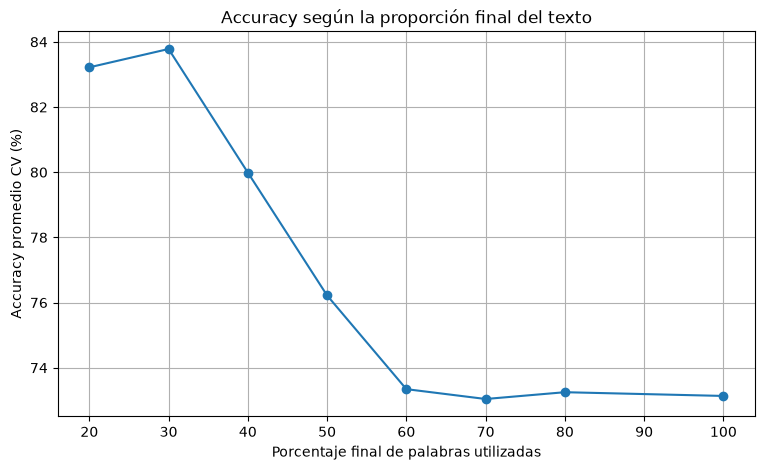

In [29]:

resultados_grafica = resultados_prop.sort_values("Proporción")

plt.figure(figsize=(9, 5))

plt.plot(
    resultados_grafica["Proporción"] * 100,
    resultados_grafica["Accuracy CV"] * 100,
    marker="o"
)

plt.title("Accuracy según la proporción final del texto")
plt.xlabel("Porcentaje final de palabras utilizadas")
plt.ylabel("Accuracy promedio CV (%)")
plt.grid(True)
plt.show()


### 14.1. Resultados de la optimización de la proporción de texto

De las ocho proporciones, la mejor fue el último 30% de las palabras, con 83,78% de accuracy promedio en validación cruzada de tres particiones. La segunda fue el último 20%, con 83,22%.

Con el 40% la accuracy baja a 79,99%, y con proporciones mayores sigue bajando hasta cerca del 73% cuando se usa casi todo el texto. Los fragmentos finales cortos son los que mejor distinguen las clases.

Como elegimos la mejor de varias proporciones con las mismas particiones, falta comprobar el resultado en el conjunto de validación. Por ahora seguimos con el último 30%.

## 15. Evaluación del modelo seleccionado

Entrenamos el pipeline con el último 30% de las palabras sobre todo el conjunto de entrenamiento y lo evaluamos en las 2.400 reseñas de validación, con accuracy, reporte de clasificación y matriz de confusión.

In [30]:
# Modelo seleccionado: último 30% del texto
pipeline_rl_30 = Pipeline([
    (
        "extraer_final",
        FunctionTransformer(
            extraer_finales_lote,
            kw_args={"proporcion": 0.30},
            validate=False
        )
    ),
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        LogisticRegression(
            C=5,
            max_iter=2000,
            random_state=42
        )
    )
])

# Entrenar solo con X_train
pipeline_rl_30.fit(X_train, y_train)

# Predecir sobre validación reservada
y_pred_30 = pipeline_rl_30.predict(X_val)

accuracy_30 = accuracy_score(y_val, y_pred_30)

print(f"Accuracy en validación: {accuracy_30:.4f}")
print(f"Accuracy en porcentaje: {accuracy_30 * 100:.2f}%")

print("\nReporte de clasificación:")
print(classification_report(y_val, y_pred_30))


Accuracy en validación: 0.8525
Accuracy en porcentaje: 85.25%

Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.82      0.79      0.80       843
     neutral       0.94      0.99      0.96       715
    positivo       0.81      0.80      0.81       842

    accuracy                           0.85      2400
   macro avg       0.86      0.86      0.86      2400
weighted avg       0.85      0.85      0.85      2400



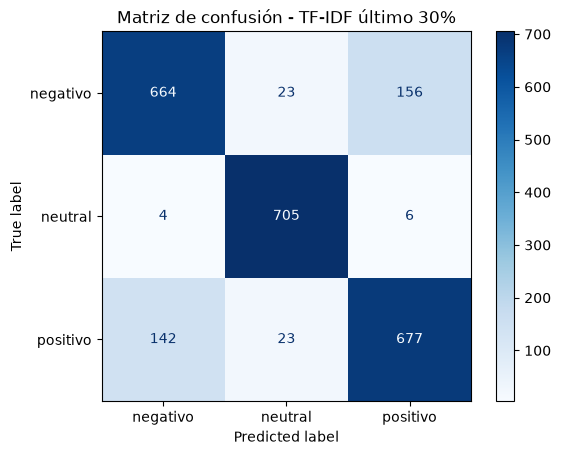

In [31]:
clases = ["negativo", "neutral", "positivo"]

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_30,
    labels=clases,
    display_labels=clases,
    cmap="Blues"
)

plt.title("Matriz de confusión - TF-IDF último 30%")
plt.show()


### 15.1. Interpretación de los resultados del modelo seleccionado

El modelo con el último 30% de las palabras obtuvo 85,25% de accuracy en validación, 12,50 puntos más que el modelo inicial con el texto completo (72,75%).

Por clase, la neutral tiene un F1-score de 0,96, y la negativa y la positiva 0,80 y 0,81. La matriz de confusión muestra 664 aciertos en negativas, 705 en neutrales y 677 en positivas. Siguen los errores entre positivo y negativo, pero son muchos menos que antes.

Usar la parte final de las reseñas mejora claramente la clasificación en este conjunto.

## 16. Ajuste final de la representación y regularización

Hacemos una búsqueda más fina alrededor de la mejor proporción, comparando el último 20%, 25%, 30% y 35% de las palabras, junto con tres valores de `C` (1, 5 y 10). Seguimos con unigramas y bigramas.

A partir de aquí usamos validación cruzada estratificada de cinco particiones sobre el entrenamiento, sin volver a usar el conjunto de validación para elegir.

In [32]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Pipeline para la búsqueda
pipeline_ajuste = Pipeline([
    (
        "extraer_final",
        FunctionTransformer(
            extraer_finales_lote,
            validate=False
        )
    ),
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

# Parámetros de búsqueda
param_grid_final = {
    "extraer_final__kw_args": [
        {"proporcion": p}
        for p in [0.20, 0.25, 0.30, 0.35]
    ],
    "modelo__C": [1, 5, 10]
}

cv_final = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_final = GridSearchCV(
    estimator=pipeline_ajuste,
    param_grid=param_grid_final,
    scoring="accuracy",
    cv=cv_final,
    n_jobs=-1,
    verbose=1
)

grid_final.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_final.best_params_)

print("\nAccuracy promedio:")
print(f"{grid_final.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros:
{'extraer_final__kw_args': {'proporcion': 0.25}, 'modelo__C': 5}

Accuracy promedio:
0.8482


### 16.1. Resultados del ajuste final de hiperparámetros

Se evaluaron 12 configuraciones con cinco particiones, es decir, 60 ajustes.

La mejor configuración usa el último 25% de las palabras y `C=5`, con 84,82% de accuracy promedio. Como la configuración salió de la misma búsqueda, comparamos directamente el 25% y el 30% con las mismas particiones para ver si la diferencia es estable.

## 17. Comparación de las mejores proporciones

Evaluamos el último 25% y el último 30% de las palabras con la misma validación cruzada de cinco particiones y los mismos parámetros de TF-IDF y Regresión Logística.

In [33]:
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

resultados_comparacion = []

for proporcion in [0.25, 0.30]:

    modelo = clone(grid_final.best_estimator_)

    modelo.set_params(
        extraer_final__kw_args={"proporcion": proporcion}
    )

    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=cv_final,
        scoring="accuracy",
        n_jobs=-1
    )

    resultados_comparacion.append({
        "Proporción": proporcion,
        "Accuracy promedio": scores.mean(),
        "Desviación estándar": scores.std(),
        "Resultados por partición": scores
    })

comparacion_final = pd.DataFrame(resultados_comparacion)

display(comparacion_final)


,Proporción,Accuracy promedio,Desviación estándar,Resultados por partición
0,0.25,0.848229,0.007998,"[0.8453125, 0.8421875, 0.8609375, 0.8536458333333333, 0.8390625]"
1,0.30,0.840833,0.006835,"[0.8395833333333333, 0.8364583333333333, 0.8447916666666667, 0.8515625, 0.8317708333333333]"


### 17.1. Resultados de la comparación de proporciones

El 25% obtuvo 84,82% de accuracy promedio (desviación estándar de 0,0080) y el 30% obtuvo 84,08% (desviación de 0,0068). La diferencia es de 0,74 puntos a favor del 25%.

Aunque la diferencia es pequeña, elegimos el 25% para el modelo que enviaremos a Kaggle.

In [ ]:
import sys
import importlib
from pathlib import Path

# Identificar la carpeta del proyecto
raiz = Path.cwd().resolve()

if raiz.name == "notebooks":
    raiz = raiz.parent

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

# Importar y recargar el módulo
import transformaciones
importlib.reload(transformaciones)

from transformaciones import extraer_finales_lote

print("Transformaciones importadas correctamente")

# Comprobar que funciona
ejemplo = ["La entrega fue rápida, pero el producto salió defectuoso"]

print(extraer_finales_lote(ejemplo, proporcion=0.25))


Transformaciones importadas correctamente
['salió defectuoso']


## 18. Entrenamiento del modelo seleccionado

El pipeline final usa el último 25% de las palabras de cada reseña, TF-IDF con unigramas y bigramas y Regresión Logística con `C=5`.

Ya elegida la configuración, lo entrenamos con las 12.000 reseñas etiquetadas para aprovechar todos los datos. El conjunto de evaluación de Kaggle solo se usa después, para predecir.

In [39]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Crear el modelo final seleccionado
modelo_rl_final = Pipeline([
    (
        "extraer_final",
        FunctionTransformer(
            extraer_finales_lote,
            kw_args={"proporcion": 0.25},
            validate=False
        )
    ),
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        LogisticRegression(
            C=5,
            max_iter=2000,
            random_state=42
        )
    )
])

# Entrenar con todos los datos etiquetados
modelo_rl_final.fit(X, y)

print("Modelo entrenado con", len(X), "reseñas")


Modelo entrenado con 12000 reseñas


## 19. Almacenamiento del modelo entrenado

Guardamos el pipeline completo con `joblib`, como se hizo en las prácticas. El archivo incluye la transformación del texto, el TF-IDF y el clasificador, así que se puede reutilizar sin volver a entrenar.

In [40]:
import joblib

# Crear la carpeta de modelos si no existe
carpeta_modelos = raiz / "models"
carpeta_modelos.mkdir(exist_ok=True)

# Definir la ubicación del archivo
ruta_modelo = carpeta_modelos / "regresion_logistica.joblib"

# Guardar el modelo entrenado
joblib.dump(modelo_rl_final, ruta_modelo)

print("Modelo guardado correctamente en:")
print(ruta_modelo)


Modelo guardado correctamente en:
/Users/laurasanchezbernal/Desktop/Proyecto-Machine-Learning/models/regresion_logistica.joblib


### 19.1. Verificación del modelo almacenado

Cargamos el archivo con `joblib.load()` y comprobamos que da las mismas predicciones que el pipeline original.

In [42]:
# Cargar el modelo
modelo_cargado = joblib.load(ruta_modelo)

# Seleccionar algunas reseñas para comprobarlo
textos_prueba = X.iloc[:10]

# Generar predicciones con ambos modelos
pred_original = modelo_rl_final.predict(textos_prueba)
pred_cargado = modelo_cargado.predict(textos_prueba)

# Verificar que sean iguales
assert np.array_equal(pred_original, pred_cargado)



## 20. Generación de predicciones para Kaggle

Con el modelo cargado generamos las predicciones para las 3.000 reseñas de `eval.csv`. El CSV sigue la estructura de `sample_submission.csv`, con las columnas `id` y `answer`, y antes de guardarlo verificamos su formato.

In [43]:
# Cargar los datos de evaluación
eval_data = pd.read_csv(raiz / "data" / "eval.csv")

# Cargar el formato de referencia
sample = pd.read_csv(
    raiz / "data" / "sample_submission.csv"
)

# Generar las predicciones
predicciones = modelo_cargado.predict(eval_data["text"])

# Construir el archivo de entrega
submission = pd.DataFrame({
    "id": eval_data["id"],
    "answer": predicciones
})

# Verificar formato y contenido
assert list(submission.columns) == list(sample.columns)
assert len(submission) == len(eval_data)
assert submission["id"].equals(eval_data["id"])
assert submission["answer"].notna().all()
assert set(submission["answer"]).issubset(set(y.unique()))

# Guardar en submissions/
carpeta_submissions = raiz / "submissions"
carpeta_submissions.mkdir(exist_ok=True)

ruta_submission = (
    carpeta_submissions / "submission_regresion_logistica.csv"
)

submission.to_csv(ruta_submission, index=False)

print("Archivo generado correctamente:")
print(ruta_submission)
print("\nDimensiones:", submission.shape)

display(submission.head())

Archivo generado correctamente:
/Users/laurasanchezbernal/Desktop/Proyecto-Machine-Learning/submissions/submission_regresion_logistica.csv

Dimensiones: (3000, 2)


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


In [44]:
import joblib
import sklearn

# Comprobar versión de scikit-learn
print("Versión de scikit-learn:", sklearn.__version__)

# Cargar el modelo guardado
modelo_verificado = joblib.load(
    raiz / "models" / "regresion_logistica.joblib"
)

# Probar una predicción
texto_prueba = [
    "El producto llegó rápido, pero dejó de funcionar."
]

prediccion = modelo_verificado.predict(texto_prueba)

print("Modelo cargado correctamente")
print("Predicción:", prediccion[0])


Versión de scikit-learn: 1.9.0
Modelo cargado correctamente
Predicción: neutral


In [45]:
# Leer el archivo CSV generado
submission_guardada = pd.read_csv(ruta_submission)

# Comprobar formato e identificadores
assert submission_guardada.equals(submission)
assert submission_guardada["id"].equals(sample["id"])
assert not submission_guardada.isnull().any().any()

print("CSV verificado correctamente")

print("\nDistribución de predicciones:")
print(submission_guardada["answer"].value_counts())


CSV verificado correctamente

Distribución de predicciones:
answer
positivo    1065
negativo    1040
neutral      895
Name: count, dtype: int64


### 20.1. Verificación del modelo y archivo de predicciones

El modelo se guardó con `joblib`, se volvió a cargar y produjo las mismas predicciones que el original. Con él generamos un CSV con las 3.000 predicciones del conjunto de evaluación, con las columnas e identificadores que pide la competencia.

El modelo se entrenó solo con las 12.000 reseñas etiquetadas; las reseñas de evaluación se usaron únicamente para predecir.

### 20.2. Análisis de las predicciones generadas

El archivo tiene las 3.000 predicciones, sin valores faltantes y con los identificadores de la plantilla.

Las predicciones se reparten en 1.065 positivas, 1.040 negativas y 895 neutrales. Es una distribución parecida a la del entrenamiento, con algo menos de neutrales, aunque eso no dice nada por sí solo sobre si las predicciones son correctas.

## 21. Evaluación en Kaggle

Hicimos el primer envío a Kaggle con la configuración seleccionada: último 25% de las palabras, unigramas y bigramas, `min_df=2`, frecuencia sublineal y `C=5`.

El archivo `submission_regresion_logistica.csv` obtuvo una accuracy pública de 83,22%, algo por debajo del 84,82% de la validación cruzada. La diferencia puede deberse al subconjunto de datos que Kaggle usa para el puntaje público.

El puntaje público no es el definitivo, así que no conviene elegir cambios solo mirando el leaderboard; seguimos usando la validación cruzada para decidir.

## 22. Análisis de las últimas oraciones de las reseñas

El modelo con el último 25% de las palabras obtuvo 84,82% en validación cruzada y 83,22% en Kaggle. Pero cortar un porcentaje fijo de palabras puede partir una oración por la mitad y perder la relación entre sus términos.

Por eso probamos usar oraciones completas: solo la última oración o las dos últimas. Pensamos que conservar la oración entera puede ayudar con contrastes, negaciones y valoraciones del final del texto. Seguimos con validación cruzada de cinco particiones y Regresión Logística.

In [46]:
import re

# Extraer las últimas oraciones de una reseña
def extraer_ultimas_oraciones(texto, cantidad=1):

    # Separar por signos de puntuación que terminan oraciones
    oraciones = re.split(r"(?<=[.!?])\s+", texto.strip())

    # Eliminar fragmentos vacíos
    oraciones = [o for o in oraciones if o.strip()]

    # Conservar las últimas oraciones
    return " ".join(oraciones[-cantidad:])


# Función para procesar varias reseñas
def extraer_oraciones_lote(textos, cantidad=1):
    return [
        extraer_ultimas_oraciones(texto, cantidad)
        for texto in textos
    ]


# Prueba sencilla
ejemplo = (
    "El producto llegó rápido. "
    "Al principio funcionaba muy bien. "
    "Después de una semana dejó de funcionar. "
    "No lo recomiendo."
)

print("Última oración:")
print(extraer_ultimas_oraciones(ejemplo, 1))

print("\nÚltimas dos oraciones:")
print(extraer_ultimas_oraciones(ejemplo, 2))


Última oración:
No lo recomiendo.

Últimas dos oraciones:
Después de una semana dejó de funcionar. No lo recomiendo.


### 22.1. Comparación de representaciones por oraciones

Entrenamos dos versiones del mismo modelo, una con la última oración y otra con las dos últimas, ambas con TF-IDF de unigramas y bigramas y `C=5`. La extracción de oraciones va dentro del pipeline para que se aplique igual en entrenamiento y en predicción.

In [47]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

resultados_oraciones = []

for cantidad in [1, 2]:

    pipeline_oraciones = Pipeline([
        (
            "extraer_oraciones",
            FunctionTransformer(
                extraer_oraciones_lote,
                kw_args={"cantidad": cantidad},
                validate=False
            )
        ),
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True
            )
        ),
        (
            "modelo",
            LogisticRegression(
                C=5,
                max_iter=2000,
                random_state=42
            )
        )
    ])

    scores = cross_val_score(
        pipeline_oraciones,
        X_train,
        y_train,
        cv=cv_final,
        scoring="accuracy",
        n_jobs=-1
    )

    resultados_oraciones.append({
        "Representación": f"Últimas {cantidad} oración(es)",
        "Accuracy promedio": scores.mean(),
        "Desviación estándar": scores.std(),
        "Resultados por partición": scores
    })

resultados_oraciones_df = pd.DataFrame(resultados_oraciones)

display(resultados_oraciones_df)


,Representación,Accuracy promedio,Desviación estándar,Resultados por partición
0,Últimas 1 oración(es),0.851042,0.010280,"[0.8536458333333333, 0.8484375, 0.865625, 0.8536458333333333, 0.8338541666666667]"
1,Últimas 2 oración(es),0.769688,0.013907,"[0.7828125, 0.7760416666666666, 0.7625, 0.78125, 0.7458333333333333]"


### 22.2. Comparación con el modelo basado en porcentaje de palabras

Comparamos estos resultados con el del último 25% de las palabras, usando la validación cruzada de cinco particiones que ya teníamos para esa configuración.

In [48]:
# Resultado previo del modelo del 25%
resultado_25 = comparacion_final.loc[
    comparacion_final["Proporción"] == 0.25
].iloc[0]

# Construir tabla comparativa
comparacion_oraciones = pd.DataFrame({
    "Representación": [
        "Último 25% de palabras",
        "Última oración",
        "Últimas dos oraciones"
    ],
    "Accuracy CV": [
        resultado_25["Accuracy promedio"],
        resultados_oraciones_df.iloc[0]["Accuracy promedio"],
        resultados_oraciones_df.iloc[1]["Accuracy promedio"]
    ],
    "Desviación estándar": [
        resultado_25["Desviación estándar"],
        resultados_oraciones_df.iloc[0]["Desviación estándar"],
        resultados_oraciones_df.iloc[1]["Desviación estándar"]
    ]
})

comparacion_oraciones["Accuracy (%)"] = (
    comparacion_oraciones["Accuracy CV"] * 100
).round(2)

display(
    comparacion_oraciones.sort_values(
        "Accuracy CV",
        ascending=False
    )
)


,Representación,Accuracy CV,Desviación estándar,Accuracy (%)
1,Última oración,0.851042,0.010280,85.10
0,Último 25% de palabras,0.848229,0.007998,84.82
2,Últimas dos oraciones,0.769688,0.013907,76.97


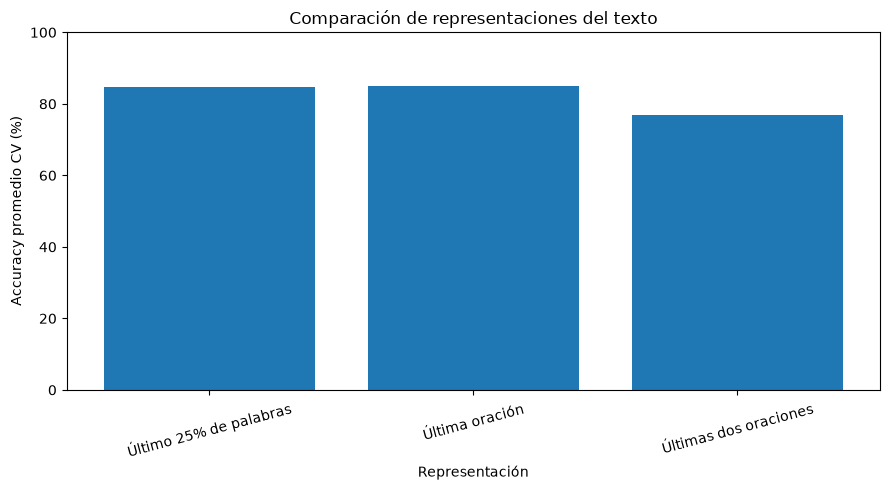

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    comparacion_oraciones["Representación"],
    comparacion_oraciones["Accuracy (%)"]
)

plt.title("Comparación de representaciones del texto")
plt.xlabel("Representación")
plt.ylabel("Accuracy promedio CV (%)")
plt.xticks(rotation=15)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


### 22.3. Interpretación de los resultados

La última oración obtuvo la mayor accuracy promedio, con 85,10%. El último 25% de palabras quedó en 84,82% y las dos últimas oraciones bajaron a 76,97%.

La última oración parece concentrar la información del sentimiento, y agregar una oración más empeora bastante el modelo. Igual, la diferencia entre la última oración y el 25% de palabras es pequeña, así que no podemos decir que una sea claramente mejor.

En la siguiente sección combinamos palabras y caracteres sobre la última oración.

## 23. Combinación de TF-IDF de palabras y caracteres sobre la última oración

Sobre la última oración combinamos TF-IDF de palabras (unigramas y bigramas) y de caracteres (secuencias de 3 a 5) con `FeatureUnion`, y usamos Regresión Logística con `C=5`. Queremos ver si los caracteres agregan algo frente a usar solo palabras.

In [50]:

from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer

# Combinar representaciones de palabras y caracteres
representacion_oracion = FeatureUnion([
    (
        "palabras",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "caracteres",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True
        )
    )
])

# Pipeline completo
pipeline_oracion_combinado = Pipeline([
    (
        "extraer_oracion",
        FunctionTransformer(
            extraer_oraciones_lote,
            kw_args={"cantidad": 1},
            validate=False
        )
    ),
    (
        "representacion",
        representacion_oracion
    ),
    (
        "modelo",
        LogisticRegression(
            C=5,
            max_iter=2000,
            random_state=42
        )
    )
])

# Evaluar mediante validación cruzada
scores_oracion_combinado = cross_val_score(
    pipeline_oracion_combinado,
    X_train,
    y_train,
    cv=cv_final,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy por partición:")
print(scores_oracion_combinado)

print("\nAccuracy promedio:")
print(f"{scores_oracion_combinado.mean():.4f}")

print("\nDesviación estándar:")
print(f"{scores_oracion_combinado.std():.4f}")


Accuracy por partición:
[0.85677083 0.84427083 0.86666667 0.85572917 0.84479167]

Accuracy promedio:
0.8536

Desviación estándar:
0.0084


In [51]:
comparacion_nueva = pd.DataFrame({
    "Modelo": [
        "Último 25% de palabras",
        "Última oración + palabras",
        "Última oración + palabras y caracteres"
    ],
    "Accuracy CV": [
        resultado_25["Accuracy promedio"],
        resultados_oraciones_df.iloc[0]["Accuracy promedio"],
        scores_oracion_combinado.mean()
    ]
})

comparacion_nueva["Accuracy (%)"] = (
    comparacion_nueva["Accuracy CV"] * 100
).round(2)

display(comparacion_nueva.sort_values(
    "Accuracy CV",
    ascending=False
))


,Modelo,Accuracy CV,Accuracy (%)
2,Última oración + palabras y caracteres,0.853646,85.36
1,Última oración + palabras,0.851042,85.10
0,Último 25% de palabras,0.848229,84.82


### 23.1. Resultados de la combinación de palabras y caracteres

La última oración con palabras y caracteres obtuvo 85,36% de accuracy promedio en validación cruzada de cinco particiones. Supera el 85,10% de la última oración solo con palabras y el 84,82% del último 25%.

La mejora frente a usar solo palabras es de 0,26 puntos, pequeña pero a favor. Tomamos esta configuración como segundo candidato para Kaggle.

## 24. Preparación del segundo modelo candidato

Entrenamos el segundo candidato (última oración con TF-IDF de palabras y caracteres) con las 12.000 reseñas etiquetadas. Lo guardamos aparte para no sobrescribir el primer modelo y generamos sus predicciones para Kaggle.

In [53]:
import importlib
import transformaciones
import joblib

from sklearn.base import clone

# Recargar e importar la función del módulo
importlib.reload(transformaciones)
from transformaciones import extraer_oraciones_lote

# Crear una copia nueva del pipeline candidato
modelo_rl_v2 = clone(pipeline_oracion_combinado)

# Asegurar el uso de la función importada
modelo_rl_v2.set_params(
    extraer_oracion__func=extraer_oraciones_lote
)

# Entrenar con los 12.000 registros etiquetados
modelo_rl_v2.fit(X, y)

# Guardar sin sobrescribir la versión anterior
ruta_v2 = raiz / "models" / "regresion_logistica_v2.joblib"

joblib.dump(modelo_rl_v2, ruta_v2)

# Comprobar que se puede cargar
modelo_v2_cargado = joblib.load(ruta_v2)

assert np.array_equal(
    modelo_rl_v2.predict(X.iloc[:10]),
    modelo_v2_cargado.predict(X.iloc[:10])
)

print("Archivo:", ruta_v2)


Archivo: /Users/laurasanchezbernal/Desktop/Proyecto-Machine-Learning/models/regresion_logistica_v2.joblib


In [54]:
# Generar predicciones con el modelo V2
predicciones_v2 = modelo_v2_cargado.predict(
    eval_data["text"]
)

submission_v2 = pd.DataFrame({
    "id": eval_data["id"],
    "answer": predicciones_v2
})

# Verificar formato
assert list(submission_v2.columns) == list(sample.columns)
assert submission_v2["id"].equals(sample["id"])
assert len(submission_v2) == 3000
assert submission_v2["answer"].notna().all()
assert set(submission_v2["answer"]).issubset(set(y.unique()))

# Guardar por separado
ruta_submission_v2 = (
    raiz / "submissions" /
    "submission_regresion_logistica_v2.csv"
)

submission_v2.to_csv(ruta_submission_v2, index=False)

print("CSV V2 generado correctamente")
print("Dimensiones:", submission_v2.shape)

print("\nDistribución de predicciones:")
print(submission_v2["answer"].value_counts())

display(submission_v2.head())


CSV V2 generado correctamente
Dimensiones: (3000, 2)

Distribución de predicciones:
answer
negativo    1075
positivo    1009
neutral      916
Name: count, dtype: int64


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


### 24.1. Generación del segundo modelo candidato

La segunda versión quedó guardada como `regresion_logistica_v2.joblib`, separada de la del primer envío.

Sus predicciones para Kaggle quedaron en 1.075 negativas, 1.009 positivas y 916 neutrales, en el archivo `submission_regresion_logistica_v2.csv`. En validación cruzada esta versión obtuvo 85,36%, frente a 84,82% del modelo anterior.

## 25. Evaluación del segundo modelo en Kaggle

Enviamos `submission_regresion_logistica_v2.csv` a Kaggle y obtuvo un puntaje público de 86,56%. Es 3,33 puntos más que el 83,22% del primer envío, y queda cerca del 85,36% de la validación cruzada.

Conservamos las dos versiones y seguimos decidiendo los cambios con validación cruzada, porque el puntaje público no es el definitivo.

## 26. Optimización de n-gramas para el tercer modelo candidato

Con V2 tenemos 85,36% en validación cruzada y 86,56% en Kaggle. Para ver si se puede mejorar, probamos otros rangos de n-gramas: agregar trigramas de palabras y ampliar el rango de caracteres.

Dejamos los demás parámetros fijos (`C=5`, `min_df=2` y frecuencia sublineal) y evaluamos con validación cruzada de cinco particiones.

In [55]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV

# Partir del pipeline V2 que ya construimos
pipeline_v3 = clone(pipeline_oracion_combinado)

# Configuraciones de n-gramas
parametros_v3 = {
    "representacion__palabras__ngram_range": [
        (1, 2),
        (1, 3)
    ],
    "representacion__caracteres__ngram_range": [
        (3, 5),
        (2, 6)
    ]
}

# Buscar la mejor combinación usando 5 particiones
grid_v3 = GridSearchCV(
    estimator=pipeline_v3,
    param_grid=parametros_v3,
    scoring="accuracy",
    cv=cv_final,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Entrenar únicamente con los datos de entrenamiento
grid_v3.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_v3.best_params_)

print("\nMejor accuracy promedio:")
print(f"{grid_v3.best_score_:.4f}")
print(f"{grid_v3.best_score_ * 100:.2f}%")


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejores hiperparámetros:
{'representacion__caracteres__ngram_range': (3, 5), 'representacion__palabras__ngram_range': (1, 3)}

Mejor accuracy promedio:
0.8547
85.47%


### 26.1. Comparación de configuraciones de n-gramas

Comparamos la accuracy promedio y la desviación estándar de las cuatro combinaciones de n-gramas, tomando V2 como referencia.

In [56]:
# Obtener los resultados de GridSearchCV
resultados_v3 = pd.DataFrame(grid_v3.cv_results_)

# Seleccionar las columnas que queremos analizar
columnas_v3 = [
    "param_representacion__palabras__ngram_range",
    "param_representacion__caracteres__ngram_range",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

comparacion_v3 = resultados_v3[columnas_v3].copy()

# Renombrar para facilitar la lectura
comparacion_v3.columns = [
    "N-gramas palabras",
    "N-gramas caracteres",
    "Accuracy CV",
    "Desviación estándar",
    "Posición"
]

comparacion_v3["Accuracy (%)"] = (
    comparacion_v3["Accuracy CV"] * 100
).round(2)

# Ordenar de mejor a peor
comparacion_v3 = comparacion_v3.sort_values(
    "Accuracy CV",
    ascending=False
)

display(comparacion_v3)


,N-gramas palabras,N-gramas caracteres,Accuracy CV,Desviación estándar,Posición,Accuracy (%)
1,"(1, 3)","(3, 5)",0.854688,0.007994,1,85.47
2,"(1, 2)","(2, 6)",0.853854,0.007501,2,85.39
0,"(1, 2)","(3, 5)",0.853646,0.008366,3,85.36
3,"(1, 3)","(2, 6)",0.853229,0.008284,4,85.32


In [57]:
accuracy_v2 = scores_oracion_combinado.mean()
accuracy_v3 = grid_v3.best_score_

diferencia = (accuracy_v3 - accuracy_v2) * 100

print(f"Accuracy V2: {accuracy_v2 * 100:.2f}%")
print(f"Mejor accuracy de búsqueda V3: {accuracy_v3 * 100:.2f}%")
print(f"Diferencia: {diferencia:+.2f} puntos porcentuales")

if diferencia > 0:
    print("\nLa búsqueda encontró una configuración con mejor promedio.")
elif diferencia < 0:
    print("\nV2 obtuvo un mejor promedio.")
else:
    print("\nLos resultados son iguales.")


Accuracy V2: 85.36%
Mejor accuracy de búsqueda V3: 85.47%
Diferencia: +0.10 puntos porcentuales

La búsqueda encontró una configuración con mejor promedio.


### 26.2. Resultados de la optimización de n-gramas

La mejor combinación usó unigramas, bigramas y trigramas de palabras con caracteres de 3 a 5, y obtuvo 85,47%. V2 obtuvo 85,36% con el mismo procedimiento.

La diferencia es de solo 0,10 puntos, así que no vale la pena cambiar. V2 sigue siendo el modelo confirmado en Kaggle.

## 27. Evaluación de pesos en la combinación de características

Como ampliar los n-gramas casi no cambió el resultado, probamos otra cosa: darle más peso a las palabras o a los caracteres dentro de la `FeatureUnion` (parámetro `transformer_weights`). Mantenemos los n-gramas de V2 y `C=5`, y evaluamos con validación cruzada de cinco particiones.

In [58]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV

# Partir de la configuración V2
pipeline_pesos = clone(pipeline_oracion_combinado)

# Probar diferentes pesos para palabras y caracteres
parametros_pesos = {
    "representacion__transformer_weights": [
        {"palabras": 1.0, "caracteres": 1.0},
        {"palabras": 1.5, "caracteres": 1.0},
        {"palabras": 2.0, "caracteres": 1.0},
        {"palabras": 1.0, "caracteres": 1.5},
        {"palabras": 1.0, "caracteres": 2.0}
    ]
}

grid_pesos = GridSearchCV(
    estimator=pipeline_pesos,
    param_grid=parametros_pesos,
    scoring="accuracy",
    cv=cv_final,
    n_jobs=-1,
    verbose=1
)

grid_pesos.fit(X_train, y_train)

print("Mejores pesos:")
print(grid_pesos.best_params_)

print("\nMejor accuracy promedio:")
print(f"{grid_pesos.best_score_:.4f}")
print(f"{grid_pesos.best_score_ * 100:.2f}%")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejores pesos:
{'representacion__transformer_weights': {'palabras': 1.0, 'caracteres': 1.0}}

Mejor accuracy promedio:
0.8536
85.36%


In [59]:
# Resultados de la búsqueda
resultados_pesos = pd.DataFrame(grid_pesos.cv_results_)

comparacion_pesos = resultados_pesos[[
    "param_representacion__transformer_weights",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

comparacion_pesos.columns = [
    "Pesos",
    "Accuracy CV",
    "Desviación estándar",
    "Posición"
]

comparacion_pesos["Accuracy (%)"] = (
    comparacion_pesos["Accuracy CV"] * 100
).round(2)

display(
    comparacion_pesos.sort_values(
        "Accuracy CV",
        ascending=False
    )
)


,Pesos,Accuracy CV,Desviación estándar,Posición,Accuracy (%)
0,"{'palabras': 1.0, 'caracteres': 1.0}",0.853646,0.008366,1,85.36
3,"{'palabras': 1.0, 'caracteres': 1.5}",0.853125,0.007519,2,85.31
4,"{'palabras': 1.0, 'caracteres': 2.0}",0.851979,0.007361,3,85.20
1,"{'palabras': 1.5, 'caracteres': 1.0}",0.851667,0.005905,4,85.17
2,"{'palabras': 2.0, 'caracteres': 1.0}",0.850313,0.007169,5,85.03


### 27.1. Resultados de la ponderación de características

De las cinco configuraciones de pesos, la mejor fue darle el mismo peso a palabras y caracteres, con 85,36%.

Al subir el peso de los caracteres a 1,5 y 2,0, la accuracy bajó a 85,31% y 85,20%. Al subir el de las palabras a 1,5 y 2,0, bajó a 85,17% y 85,03%. Por lo tanto, dejamos los pesos de V2 como estaban.

## 28. Análisis final de las características del conjunto de datos

Durante el proyecto vimos que los modelos que usan la parte final de las reseñas funcionan mejor que los que usan el texto completo. V2, con la última oración y TF-IDF de palabras y caracteres, obtuvo 85,36% en validación cruzada y 86,56% en Kaggle.

Para entender por qué, analizamos las últimas oraciones y su relación con las etiquetas, usando solo los datos de entrenamiento.

In [60]:
from transformaciones import extraer_ultimas_oraciones

# Crear una copia de los datos etiquetados
analisis_final = pd.DataFrame({
    "text": X,
    "label": y
}).copy()

# Extraer la última oración
analisis_final["ultima_oracion"] = (
    analisis_final["text"].apply(
        lambda texto: extraer_ultimas_oraciones(texto, 1)
    )
)

# Calcular longitudes
analisis_final["palabras_texto"] = (
    analisis_final["text"].str.split().str.len()
)

analisis_final["palabras_ultima_oracion"] = (
    analisis_final["ultima_oracion"].str.split().str.len()
)

# Calcular la proporción de palabras conservadas
analisis_final["proporcion_final"] = (
    analisis_final["palabras_ultima_oracion"]
    / analisis_final["palabras_texto"]
)

# Resumen por sentimiento
resumen_longitudes = analisis_final.groupby("label")[
    ["palabras_ultima_oracion", "proporcion_final"]
].agg(["mean", "median", "std"])

display(resumen_longitudes)


palabras_ultima_oracion                  proporcion_final            \
                            mean median       std             mean    median   
label                                                                          
negativo               12.106363   11.0  5.506248         0.235896  0.209677   
neutral                12.199944   12.0  4.562726         0.252800  0.227273   
positivo               12.132004   11.0  5.648507         0.233310  0.204082   

                    
               std  
label               
negativo  0.129397  
neutral   0.134280  
positivo  0.130115

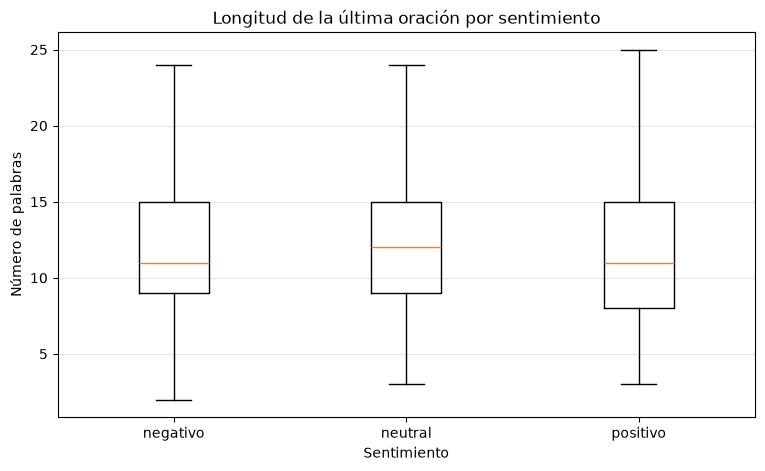

In [61]:
import matplotlib.pyplot as plt

orden = ["negativo", "neutral", "positivo"]

datos_grafica = [
    analisis_final.loc[
        analisis_final["label"] == clase,
        "palabras_ultima_oracion"
    ]
    for clase in orden
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    datos_grafica,
    tick_labels=orden,
    showfliers=False
)

plt.title("Longitud de la última oración por sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Número de palabras")
plt.grid(axis="y", alpha=0.3)
plt.show()


### 28.1. Interpretación de las características aprendidas por la Regresión Logística

Revisamos los coeficientes de V2, que corresponden a unigramas y bigramas de palabras y a secuencias de caracteres, para ver qué términos se asocian más con cada clase. Como en la práctica de Regresión Logística, los coeficientes son asociaciones aprendidas por el modelo, no relaciones causales.

In [62]:
import numpy as np
import pandas as pd

# Utilizar el modelo V2 guardado
modelo_analisis = modelo_v2_cargado

# Obtener las representaciones
vectorizador = modelo_analisis.named_steps["representacion"]

# Obtener el clasificador
clasificador = modelo_analisis.named_steps["modelo"]

# Obtener nombres de las características
caracteristicas = vectorizador.get_feature_names_out()

# Categorías en el orden interno del clasificador
clases_modelo = clasificador.classes_

# Coeficientes aprendidos
coeficientes = clasificador.coef_

for i, clase in enumerate(clases_modelo):

    indices = np.argsort(coeficientes[i])[-15:][::-1]

    tabla = pd.DataFrame({
        "Característica": caracteristicas[indices],
        "Coeficiente": coeficientes[i][indices]
    })

    print(f"\nCaracterísticas asociadas a: {clase}")
    display(tabla)



Características asociadas a: negativo


,Característica,Coeficiente
0,palabras__mal,3.918411
1,palabras__poco fiable,3.615943
2,palabras__deficiente,3.096547
3,palabras__pobre,2.943629
4,caracteres__ mal,2.778366
5,palabras__desagradable,2.617585
6,caracteres__mal,2.563247
7,palabras__olvidable,2.528129
8,palabras__corriente,2.495044
9,palabras__terrible,2.492490



Características asociadas a: neutral


,Característica,Coeficiente
0,palabras__viene,2.444829
1,palabras__solo,1.838014
2,palabras__por,1.755216
3,palabras__pesa,1.729681
4,palabras__diario desde,1.696222
5,palabras__dato,1.625769
6,palabras__tengo en,1.595016
7,palabras__trae,1.581484
8,palabras__por ahora,1.575708
9,palabras__tardes después,1.498456



Características asociadas a: positivo


,Característica,Coeficiente
0,palabras__eficiente,3.077863
1,palabras__decente,2.966719
2,palabras__resistente,2.580575
3,palabras__impecable,2.534967
4,palabras__agradable,2.526509
5,palabras__potente,2.454457
6,palabras__veloz,2.409312
7,palabras__cumplidor,2.407873
8,palabras__preciso,2.391528
9,palabras__precisa,2.381244


### 28.2. Inspección cualitativa de las últimas oraciones

Revisamos algunas reseñas de cada clase, mostrando el texto completo y la última oración que extrae V2. Queremos ver si la última oración basta para identificar el sentimiento o si a veces depende de lo que se dice antes.

In [63]:
# Seleccionar cinco reseñas por sentimiento
for clase in ["negativo", "neutral", "positivo"]:

    ejemplos = analisis_final[
        analisis_final["label"] == clase
    ].sample(
        n=5,
        random_state=42
    )

    print("\n" + "=" * 60)
    print("SENTIMIENTO:", clase.upper())
    print("=" * 60)

    for _, fila in ejemplos.iterrows():

        print("\nRESEÑA COMPLETA:")
        print(fila["text"])

        print("\nÚLTIMA ORACIÓN:")
        print(fila["ultima_oracion"])

        print("-" * 60)



SENTIMIENTO: NEGATIVO

RESEÑA COMPLETA:
La compré en noviembre en una oferta del buen fin, llegó en cuatro días. En pocas palabras, la cámara no es para nada lo que esperaba. La uso nomás para fotos casuales en casa. Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó.

ÚLTIMA ORACIÓN:
Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó.
------------------------------------------------------------

RESEÑA COMPLETA:
Lo compre hace poco por internet porque queria reemplazar uno viejo que tenia en la casa. Me llego en unos trs dias. La autonoia me salio eficiente para lo que necesitaba, la uso a diario en las mananas. Eso si, el tamano es de mala calidad hasta ahora.

ÚLTIMA ORACIÓN:
Eso si, el tamano es de mala calidad hasta ahora.
------------------------------------------------------------

RESEÑA COMPLETA:
Llevo ya un rato con él, lo compré para usar en la cocina de mi casa y llegó en tres días. En mi opinión

### 28.3. Análisis de errores del modelo V2

Por último, revisamos reseñas mal clasificadas por V2 usando predicciones de validación cruzada, sobre todo las confusiones entre positivo y negativo, para ver en qué casos la última oración no alcanza.

In [64]:

from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, classification_report

# Predicciones fuera de muestra mediante CV
predicciones_cv = cross_val_predict(
    clone(pipeline_oracion_combinado),
    X_train,
    y_train,
    cv=cv_final,
    n_jobs=-1
)

# Construir tabla de análisis
errores_v2 = pd.DataFrame({
    "texto": X_train.to_numpy(),
    "real": y_train.to_numpy(),
    "prediccion": predicciones_cv
})

# Conservar solamente los errores
errores_v2 = errores_v2[
    errores_v2["real"] != errores_v2["prediccion"]
].copy()

# Extraer la última oración
errores_v2["ultima_oracion"] = (
    errores_v2["texto"].apply(
        lambda texto: extraer_ultimas_oraciones(texto, 1)
    )
)

print("Cantidad de errores:", len(errores_v2))

print("\nPrincipales confusiones:")
display(
    pd.crosstab(
        errores_v2["real"],
        errores_v2["prediccion"]
    )
)

print("\nEjemplos de errores:")
display(
    errores_v2[
        ["ultima_oracion", "real", "prediccion"]
    ].sample(
        n=min(10, len(errores_v2)),
        random_state=42
    )
)


Cantidad de errores: 1405

Principales confusiones:


prediccion,negativo,neutral,positivo
real,,,
negativo,0,122,487
neutral,33,0,67
positivo,538,158,0



Ejemplos de errores:


,ultima_oracion,real,prediccion
7174,Todavía no me decido si quedármelo o buscar otra opción.,negativo,positivo
3415,Ni lo mejor ni lo peor.,negativo,positivo
4414,Lo dejo a tu criterio.,negativo,positivo
4470,"En fin, ni fu ni fa.",positivo,negativo
6489,Lo dejé conectado en la mesita de noche y ahí sigue.,negativo,neutral
2290,"A fin de cuentas, el menu de ajustes me parecio correcot despues de un mes.",positivo,negativo
7854,Ni lo mejor ni lo peor.,negativo,positivo
744,Cada quien que juzgue.,positivo,negativo
522,"El servicio terminó siendo decepcionante para lo que necesitaba, pero al final el control remoto resultó decente para el precio que tiene.",positivo,negativo
5163,Ni lo mejor ni lo peor.,negativo,positivo


### 28.4. Interpretación de la longitud de las últimas oraciones

La última oración tiene una longitud promedio parecida en las tres clases: 12,11 palabras en las negativas, 12,20 en las neutrales y 12,13 en las positivas. En promedio representa el 23,59% del texto en las negativas, el 25,28% en las neutrales y el 23,33% en las positivas.

Las distribuciones de longitud se superponen bastante, así que la longitud de la última oración no explica el buen desempeño del modelo. Lo que importa parece ser su contenido.

### 28.5. Interpretación de las características aprendidas

En la clase negativa aparecen términos como "mal", "poco fiable", "deficiente", "desagradable", "terrible" y "decepcionante", que describen malas experiencias con la calidad o el funcionamiento.

En la positiva destacan "eficiente", "resistente", "impecable", "agradable", "potente" y "durable".

En la neutral aparecen palabras como "viene", "pesa", "dato", "trae" y "caja", que sirven más para describir el producto que para valorarlo.

El modelo aprendió asociaciones razonables, aunque eso no significa que entienda bien expresiones ambiguas, negaciones u opiniones mixtas.

### 28.6. Interpretación de los errores de clasificación

Con validación cruzada, V2 tuvo 1.405 errores en las 9.600 reseñas de entrenamiento, lo que equivale a una accuracy de 85,36%.

La mayor dificultad sigue siendo positivo contra negativo: 538 positivas se clasificaron como negativas y 487 negativas como positivas. Las confusiones con la clase neutral son menos.

Entre los errores hay expresiones ambiguas como "Ni lo mejor ni lo peor", "Lo dejo a tu criterio" y "Todavía no me decido si quedármelo o buscar otra opción", y también reseñas que mezclan aspectos buenos y malos del producto. En estos casos el sentimiento global puede depender de algo que se dice antes de la última oración.

Esa es la principal limitación del modelo: la última oración concentra mucha información, pero no siempre resume bien la valoración completa de la reseña.

## 29. Conclusiones finales

En este notebook evaluamos varias formas de representar el texto con TF-IDF para clasificar sentimientos con Regresión Logística.

Empezamos con el texto completo, usando unigramas y después unigramas y bigramas, con resultados cercanos al 73%. El análisis de errores mostró que el problema principal era distinguir reseñas positivas de negativas.

Al revisar esos errores planteamos que las expresiones del final de las reseñas eran las más importantes para el sentimiento. Lo comprobamos comparando distintas proporciones finales del texto y oraciones completas: la última oración dio mejores resultados que las configuraciones con el texto completo.

Después combinamos TF-IDF de palabras (unigramas y bigramas) y de caracteres (3 a 5) sobre la última oración. Esta configuración, V2, obtuvo 85,36% en validación cruzada de cinco particiones. Entrenada con las 12.000 reseñas, obtuvo 86,56% en el puntaje público de Kaggle, frente al 83,22% de la primera versión.

También probamos otros rangos de n-gramas y distintos pesos para palabras y caracteres. La configuración con trigramas llegó a 85,47%, una diferencia demasiado pequeña para reemplazar a V2.

Los coeficientes del modelo muestran asociaciones coherentes entre términos de calidad, funcionamiento y satisfacción y cada sentimiento. La longitud de la última oración es parecida en las tres clases, así que no explica por sí sola el desempeño.

Los errores que quedan se deben sobre todo a expresiones ambiguas, negaciones, opiniones mixtas y a la información que se pierde al quedarse solo con la última oración.

V2 es la mejor configuración de Regresión Logística que enviamos a Kaggle. Los resultados corresponden a este conjunto de datos y al puntaje público, que puede diferir del puntaje privado final.